In [1]:

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import structural_similarity as ssim


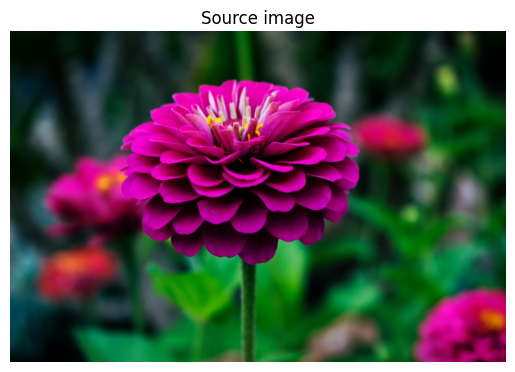

In [3]:
# Загрузка исходного изображние 

img = cv2.cvtColor(cv2.imread('img.jpg'), cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('Source image')
plt.axis('off')
plt.show()

In [10]:
# 1. Зашумить изображение при помощи шума гаусса, постоянного шума.


def add_gaussian_noise(image, sigma=30, mu=0):
    """Добавляет гауссов шум к изображению"""
    noise = np.random.normal(mu, sigma, image.shape)
    noisy = image.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def add_salt_pepper_noise(image, salt_ratio=0.05, pepper_ratio=0.05):
    """Добавляет импульсный шум ("соль-перец")"""
    noisy = image.copy()
    total_pixels = image.shape[0] * image.shape[1]

    # Случайные координаты для "соли"
    num_salt = int(total_pixels * salt_ratio)
    coords_salt = (np.random.randint(0, image.shape[0], num_salt),
                   np.random.randint(0, image.shape[1], num_salt))
    noisy[coords_salt] = 255

    # Случайные координаты для "перца"
    num_pepper = int(total_pixels * pepper_ratio)
    coords_pepper = (np.random.randint(0, image.shape[0], num_pepper),
                     np.random.randint(0, image.shape[1], num_pepper))
    noisy[coords_pepper] = 0

    return noisy

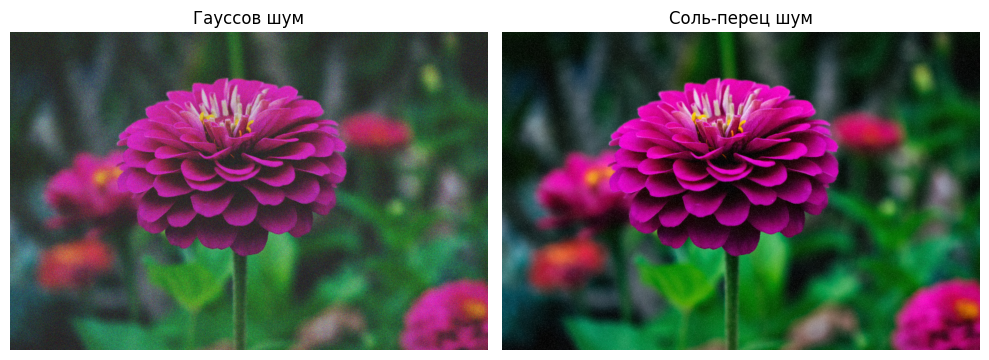

In [11]:

# --- Применение функций ---
gaussian_noisy = add_gaussian_noise(img, sigma=100)
sp_noisy = add_salt_pepper_noise(img, salt_ratio=0.03, pepper_ratio=0.03)

# --- Отображение ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gaussian_noisy)
axes[0].set_title("Гауссов шум")
axes[0].axis('off')

axes[1].imshow(sp_noisy)
axes[1].set_title("Соль-перец шум")
axes[1].axis('off')

plt.tight_layout()
plt.show()



In [12]:
# --- Тестирование фильтров ---
def try_median_filters(noisy_img):
    """Медианные фильтры разных размеров"""
    return {
        "median_3": cv2.medianBlur(noisy_img, 3),
        "median_5": cv2.medianBlur(noisy_img, 5),
        "median_7": cv2.medianBlur(noisy_img, 7)
    }


def try_gaussian_filters(noisy_img):
    """Гауссовы фильтры с разными параметрами"""
    return {
        "gauss_3": cv2.GaussianBlur(noisy_img, (3, 3), 0),
        "gauss_5": cv2.GaussianBlur(noisy_img, (5, 5), 1),
        "gauss_7": cv2.GaussianBlur(noisy_img, (7, 7), 2)
    }


def try_bilateral_filters(noisy_img):
    """Билатеральные фильтры с разными настройками"""
    return {
        "bilateral_5_50": cv2.bilateralFilter(noisy_img, 5, 50, 50),
        "bilateral_9_75": cv2.bilateralFilter(noisy_img, 9, 75, 75),
        "bilateral_15_100": cv2.bilateralFilter(noisy_img, 15, 100, 100)
    }


def try_nlm_filters(noisy_img):
    """Фильтры нелокальных средних"""
    return {
        "nlm_10": cv2.fastNlMeansDenoisingColored(noisy_img, None, 10, 10, 7, 21),
        "nlm_15": cv2.fastNlMeansDenoisingColored(noisy_img, None, 15, 15, 7, 21),
        "nlm_20": cv2.fastNlMeansDenoisingColored(noisy_img, None, 20, 20, 7, 21)
    }


In [7]:
def calculate_psnr(original, filtered):
    mse = np.mean((original.astype(float) - filtered.astype(float)) ** 2)
    return 20 * np.log10(255.0 / np.sqrt(mse)) if mse != 0 else float('inf')

def calculate_ssim(original, filtered):
    if len(original.shape) == 3:
        original = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
        filtered = cv2.cvtColor(filtered, cv2.COLOR_RGB2GRAY)
    return ssim(original, filtered)

In [13]:
def evaluate_filters(original_img, noisy_img):
    """Оценивает качество работы различных фильтров (PSNR и SSIM)."""
    
    # собираем все варианты фильтрации
    all_results = {}
    all_results |= try_median_filters(noisy_img)
    all_results |= try_gaussian_filters(noisy_img)
    all_results |= try_bilateral_filters(noisy_img)
    all_results |= try_nlm_filters(noisy_img)

    metrics = []
    for name, filtered_img in all_results.items():
        psnr_value = calculate_psnr(original_img, filtered_img)
        ssim_value = calculate_ssim(original_img, filtered_img)
        metrics.append((name, psnr_value, ssim_value, filtered_img))

    # сортировка по PSNR (от лучшего к худшему)
    metrics.sort(key=lambda x: x[1], reverse=True)
    return metrics


def display_top_results(metrics, original, noisy, noise_kind):
    """Выводит лучшие результаты фильтрации с визуализацией."""
    
    print(f"\nТест фильтров для шума: {noise_kind}")
    print("-" * 45)
    for i, (name, psnr, ssim, _) in enumerate(metrics[:5], start=1):
        print(f"{i}. {name:20s} | PSNR: {psnr:.2f} dB | SSIM: {ssim:.4f}")

    # отображаем 5 лучших результатов
    plt.figure(figsize=(18, 6))
    for i, (name, _, _, filtered_img) in enumerate(metrics[:5], start=1):
        plt.subplot(1, 5, i)
        plt.imshow(filtered_img)
        plt.title(name)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


        


1. median_7: PSNR = 23.71 dB, SSIM = 0.4597
2. median_5: PSNR = 21.11 dB, SSIM = 0.2963
3. gauss_7: PSNR = 19.06 dB, SSIM = 0.5077
4. gauss_5: PSNR = 17.81 dB, SSIM = 0.2668
5. median_3: PSNR = 17.27 dB, SSIM = 0.1356


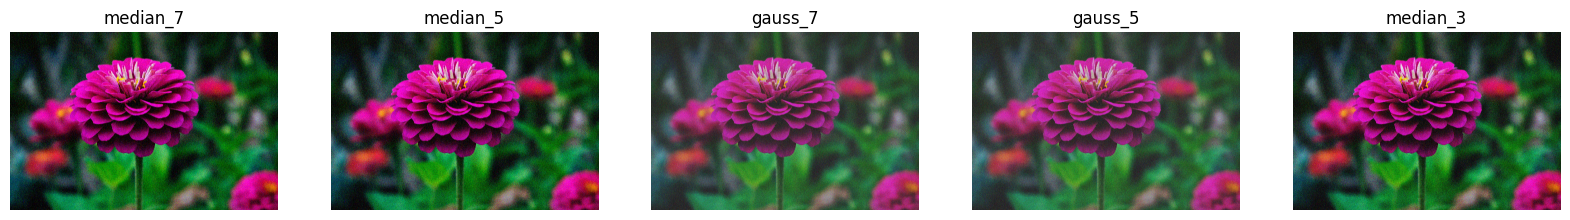

In [9]:

show_results(analyze_img(img, gn_img), img, gn_img, 'шум гаусса');

1. median_3: PSNR = 38.24 dB, SSIM = 0.9061
2. median_5: PSNR = 37.15 dB, SSIM = 0.8553
3. median_7: PSNR = 37.10 dB, SSIM = 0.8539
4. gauss_7: PSNR = 26.46 dB, SSIM = 0.5840
5. gauss_5: PSNR = 23.80 dB, SSIM = 0.3449


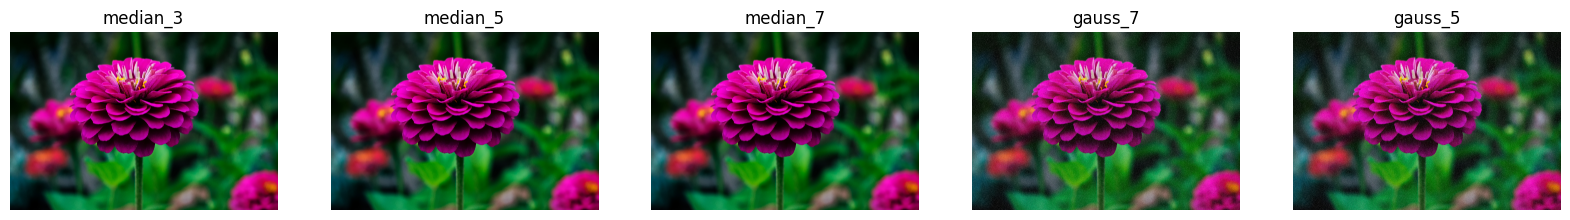

In [29]:
show_results(analyze_img(img, spn_img), img, spn_img, 'salp-pepper');